C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_25204\3251812066.py:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('inflation and economic growth.csv', parse_dates=['Date'])


Train R²: 0.3117
Test R²: -0.3788
Train RMSE: 1.2332
Test RMSE: 4.2071


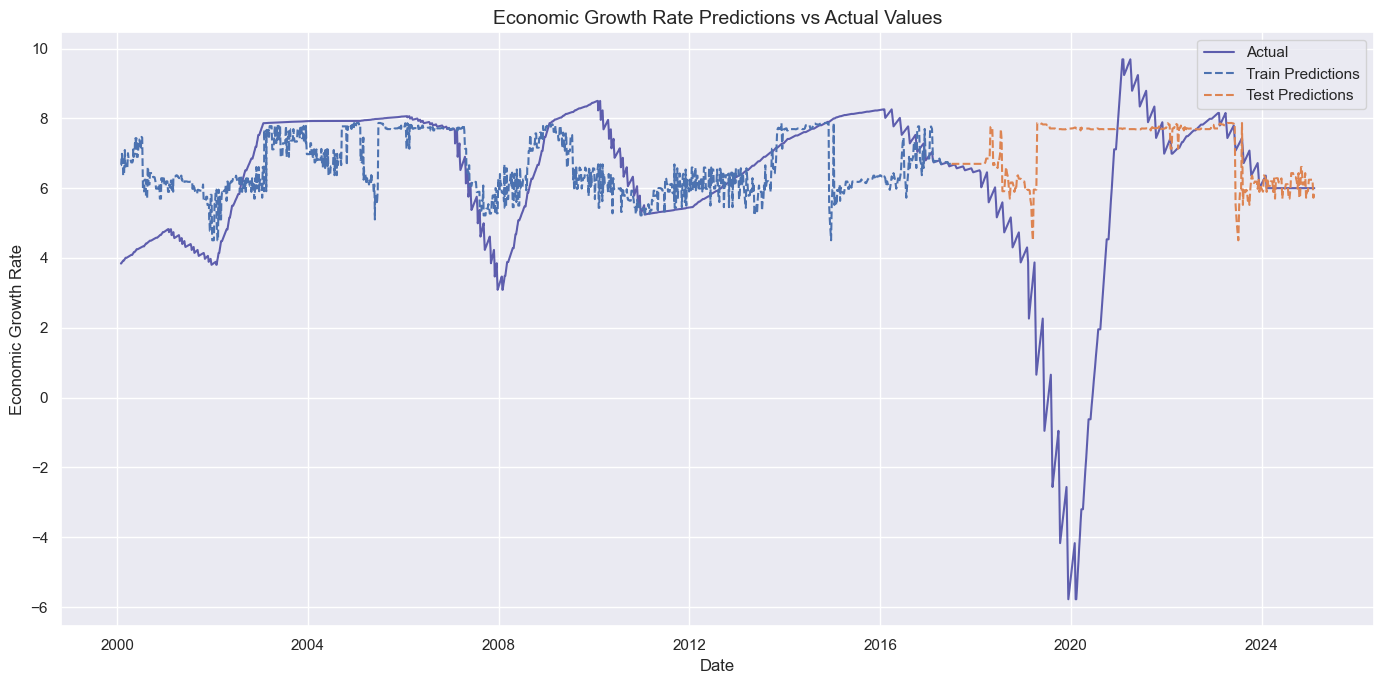

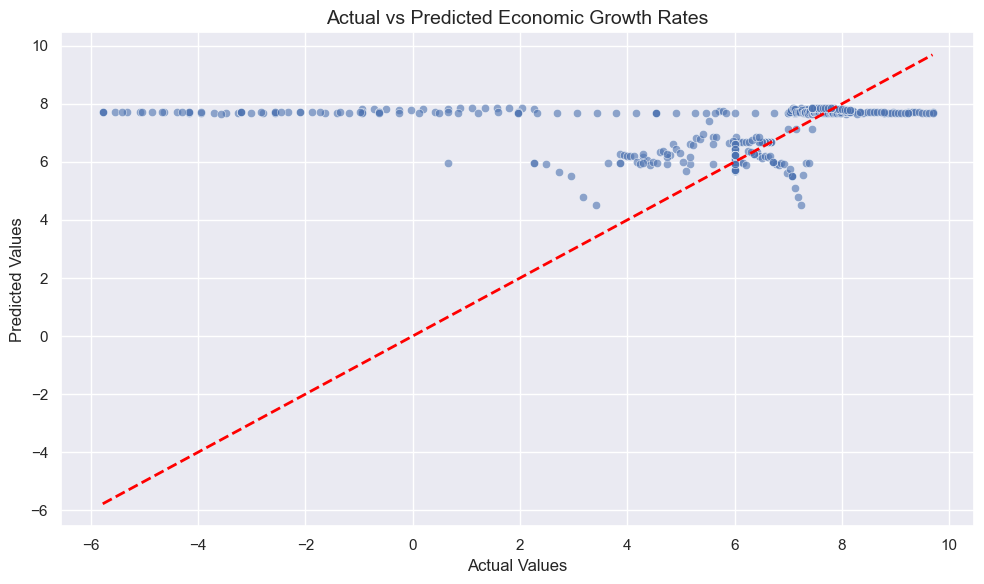

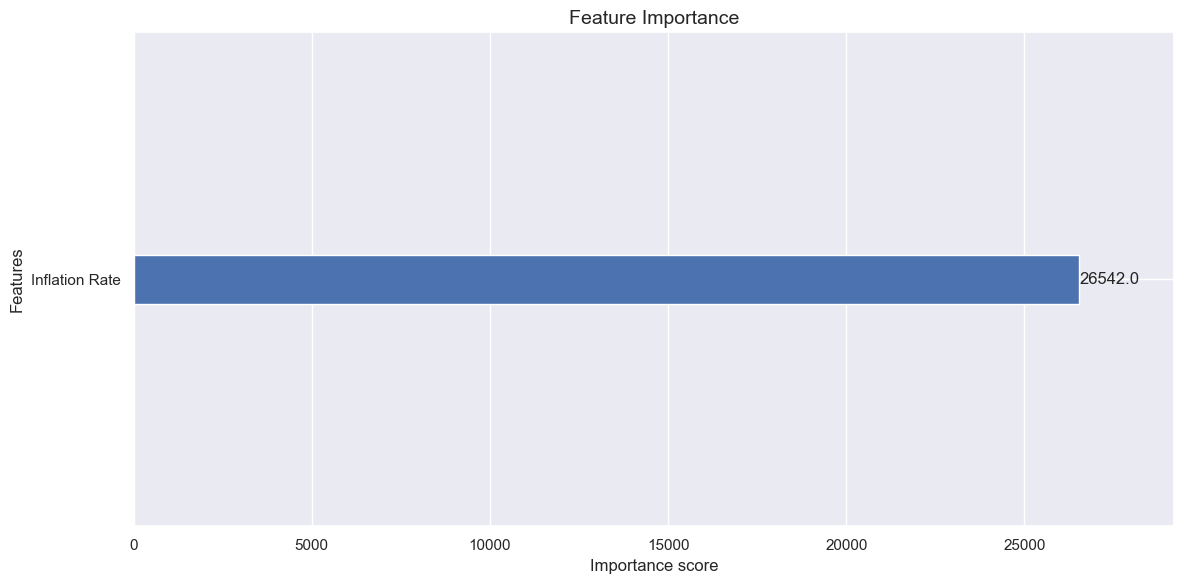

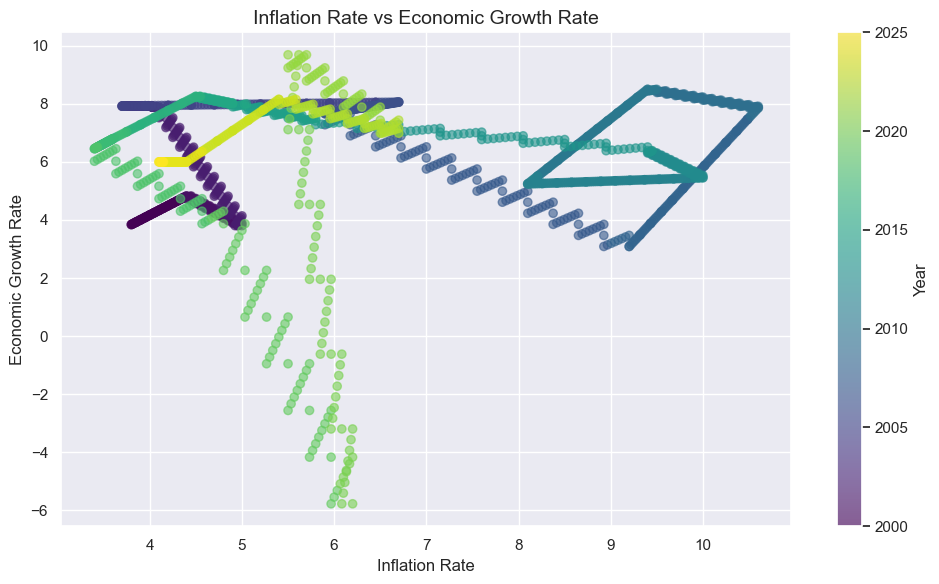

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import joblib
import seaborn as sns
sns.set()

# Load and preprocess data
df = pd.read_csv('inflation and economic growth.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# Create features and target
X = df[['Inflation Rate']]
y = df['Economic Growth Rate']

# Time-based train-test split
train_size = int(0.8 * len(df))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Train XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.01)
model.fit(X_train, y_train)

# Generate predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Save model
joblib.dump(model, 'economic_growth_xgboost_model.pkl')

# Evaluation metrics
print(f"Train R²: {r2_score(y_train, train_pred):.4f}")
print(f"Test R²: {r2_score(y_test, test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")

# Plotting settings
# plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = (12, 6)

# Time series plot
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Economic Growth Rate'], label='Actual', color='navy', alpha=0.6)
plt.plot(df['Date'][:train_size], train_pred, label='Train Predictions', linestyle='--')
plt.plot(df['Date'][train_size:], test_pred, label='Test Predictions', linestyle='--')
plt.title('Economic Growth Rate Predictions vs Actual Values', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Economic Growth Rate', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('growth_predictions.png')
plt.show()

# Scatter plot of predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', lw=2, color='red')
plt.title('Actual vs Predicted Economic Growth Rates', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

# Feature importance plot
xgb.plot_importance(model, importance_type='weight')
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Inflation vs Growth analysis plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Inflation Rate'], df['Economic Growth Rate'], alpha=0.6, c=df['Date'].dt.year, cmap='viridis')
plt.colorbar(label='Year')
plt.title('Inflation Rate vs Economic Growth Rate', fontsize=14)
plt.xlabel('Inflation Rate', fontsize=12)
plt.ylabel('Economic Growth Rate', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('inflation_vs_growth.png')
plt.show()

R² Score: 0.074
MSE: 4.296


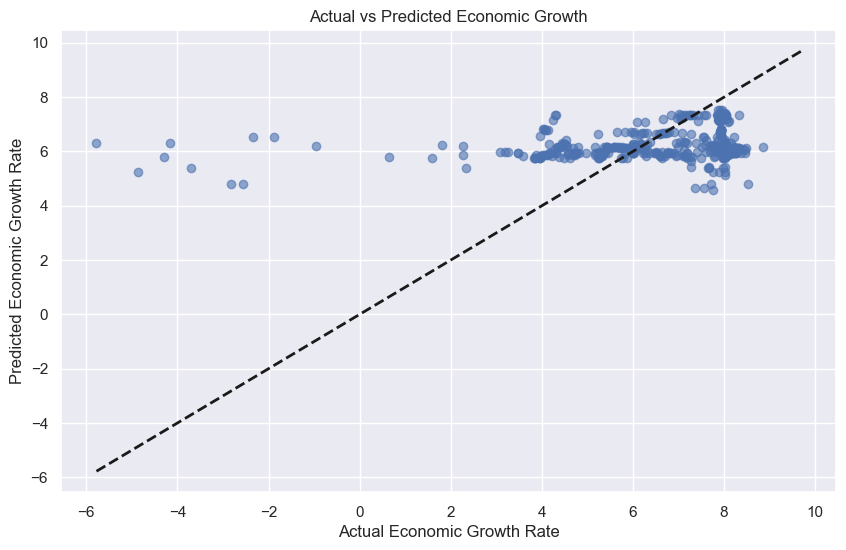

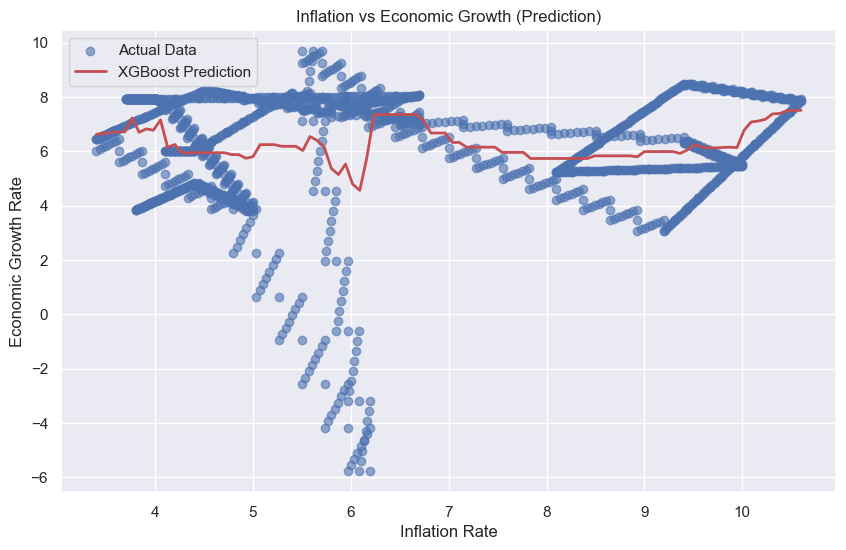

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load and clean data
data = pd.read_csv('inflation and economic growth.csv')
data = data.dropna(subset=['Inflation Rate', 'Economic Growth Rate'])

# Features and target
X = data[['Inflation Rate']]
y = data['Economic Growth Rate']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix for native XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.9,
    'colsample_bytree': 0.7
}

# Train model
model = xgb.train(params, dtrain, num_boost_round=1000,
                  evals=[(dtest, 'eval')],
                  early_stopping_rounds=20,
                  verbose_eval=False)

# Predict on test set
y_pred = model.predict(dtest)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Economic Growth Rate')
plt.ylabel('Predicted Economic Growth Rate')
plt.title('Actual vs Predicted Economic Growth')
plt.grid(True)
plt.show()

# Plot relationship: Inflation vs Predicted Economic Growth
plt.figure(figsize=(10, 6))

# Create test range for inflation
inflation_range = pd.DataFrame(
    np.linspace(data['Inflation Rate'].min(), data['Inflation Rate'].max(), 100),
    columns=['Inflation Rate']
)
inflation_dmatrix = xgb.DMatrix(inflation_range)

predicted_growth = model.predict(inflation_dmatrix)

plt.scatter(data['Inflation Rate'], data['Economic Growth Rate'], alpha=0.6, label='Actual Data')
plt.plot(inflation_range, predicted_growth, 'r-', lw=2, label='XGBoost Prediction')
plt.xlabel('Inflation Rate')
plt.ylabel('Economic Growth Rate')
plt.title('Inflation vs Economic Growth (Prediction)')
plt.legend()
plt.grid(True)
plt.show()
